In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb

from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")

BASE_DIR = r"E:\Research\Paper_A_XAI_IDS"
PROCESSED_DIR = os.path.join(BASE_DIR, "02_Data", "processed")
RESULTS_DIR = os.path.join(BASE_DIR, "04_Results", "metrics")
FIG_DIR = os.path.join(BASE_DIR, "05_Figures", "raw")
NOTES_DIR = os.path.join(BASE_DIR, "07_Notes")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(NOTES_DIR, exist_ok=True)

In [2]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train_final.csv"))
X_val = pd.read_csv(os.path.join(PROCESSED_DIR, "X_val_final.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test_final.csv"))

y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train_binary.csv")).squeeze("columns")
y_val = pd.read_csv(os.path.join(PROCESSED_DIR, "y_val_binary.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test_binary.csv")).squeeze("columns")

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.value_counts())

(100778, 122) (25195, 122) (22544, 122)
binary_label
0    53874
1    46904
Name: count, dtype: int64


In [3]:
baseline_results = pd.read_csv(os.path.join(RESULTS_DIR, "baseline_validation_results.csv"))
baseline_results.sort_values("f1", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
0,LightGBM,0.999405,0.999488,0.999232,0.999360,0.999997
1,XGBoost,0.999365,0.999403,0.999232,0.999318,0.999992
2,RandomForest,0.999087,0.999488,0.998550,0.999019,0.999995
3,LogisticRegression,0.880492,0.894808,0.842231,0.867724,0.949960


In [4]:
best_model_name = baseline_results.sort_values("f1", ascending=False).iloc[0]["model"]
best_model_name

'LightGBM'

In [5]:
import joblib

# If you saved the model earlier, load it here.
# Otherwise, refit LightGBM directly from the processed train split.
try:
    model_path = os.path.join(RESULTS_DIR, f"{best_model_name}_model.pkl")
    model = joblib.load(model_path)
    print("Loaded model:", best_model_name)
except Exception:
    model = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=-1, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    print("Refit LightGBM model")

[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3262
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
Refit LightGBM model


In [6]:
sample_X = X_val.sample(n=min(2000, len(X_val)), random_state=42)
sample_y = y_val.loc[sample_X.index]
sample_X = sample_X.reset_index(drop=True)
sample_y = sample_y.reset_index(drop=True)

print(sample_X.shape)

(2000, 122)


In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_X)

type(shap_values), len(shap_values) if isinstance(shap_values, list) else shap_values.shape

(numpy.ndarray, (2000, 122))

In [8]:
# For binary LightGBM, use the positive-class SHAP values
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
else:
    shap_pos = shap_values

print(shap_pos.shape)

(2000, 122)


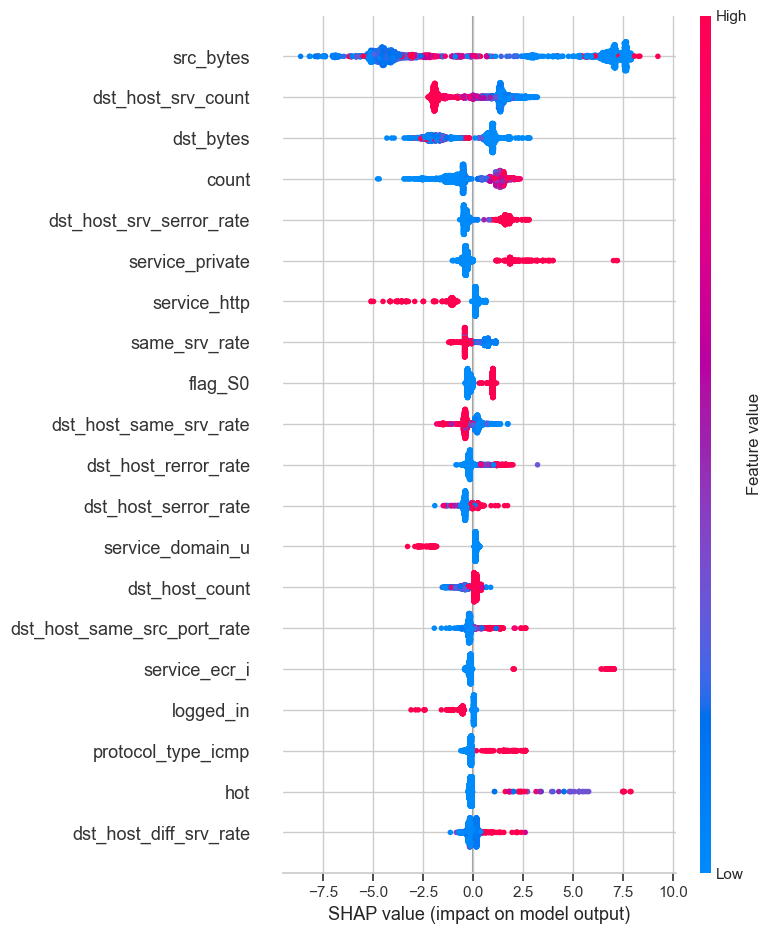

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_summary_lightgbm_positive_class.png


In [9]:
shap.summary_plot(shap_pos, sample_X, show=False)
plt.tight_layout()

summary_path = os.path.join(FIG_DIR, "shap_summary_lightgbm_positive_class.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", summary_path)

In [10]:
mean_abs_shap = np.abs(shap_pos).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": sample_X.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

importance_df.head(20)

,feature,mean_abs_shap
1,src_bytes,5.350798
29,dst_host_srv_count,1.514482
2,dst_bytes,1.377499
19,count,1.089730
35,dst_host_srv_serror_rate,0.730447
90,service_private,0.656116
65,service_http,0.524480
25,same_srv_rate,0.483589
116,flag_S0,0.395857
30,dst_host_same_srv_rate,0.363808


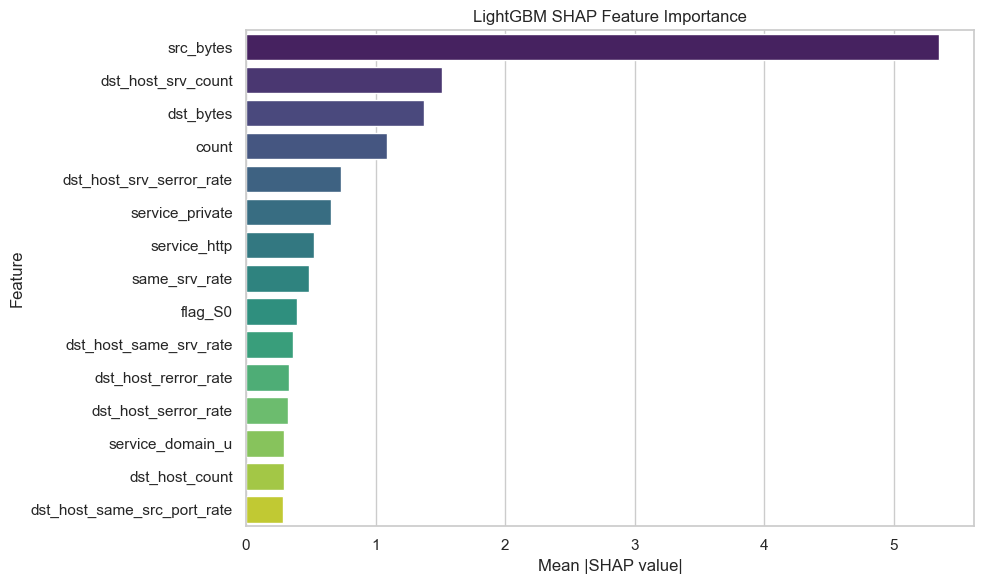

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_feature_importance_lightgbm.png


In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="mean_abs_shap", y="feature", palette="viridis")
plt.title("LightGBM SHAP Feature Importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()

bar_path = os.path.join(FIG_DIR, "shap_feature_importance_lightgbm.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bar_path)

In [12]:
importance_path = os.path.join(RESULTS_DIR, "shap_feature_importance_lightgbm.csv")
importance_df.to_csv(importance_path, index=False)
print("Saved:", importance_path)

Saved: E:\Research\Paper_A_XAI_IDS\04_Results\metrics\shap_feature_importance_lightgbm.csv


In [13]:
top_features = importance_df["feature"].head(3).tolist()
top_features

['src_bytes', 'dst_host_srv_count', 'dst_bytes']

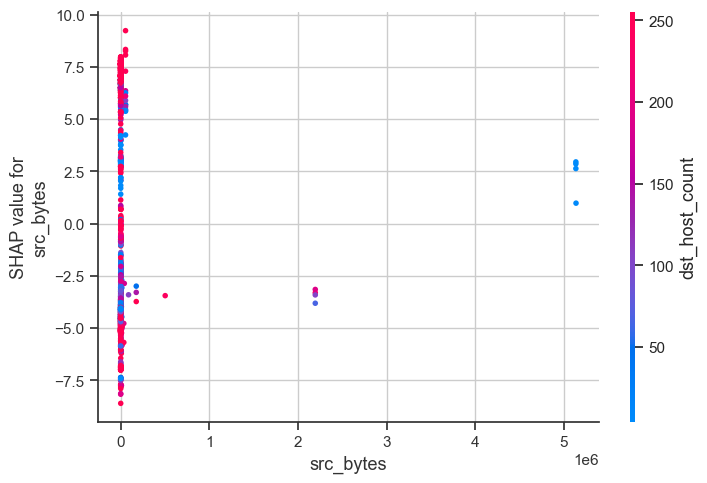

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_dependence_src_bytes.png


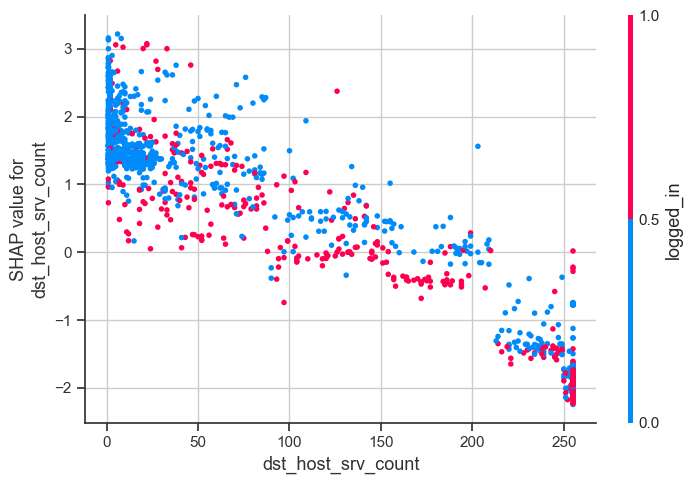

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_dependence_dst_host_srv_count.png


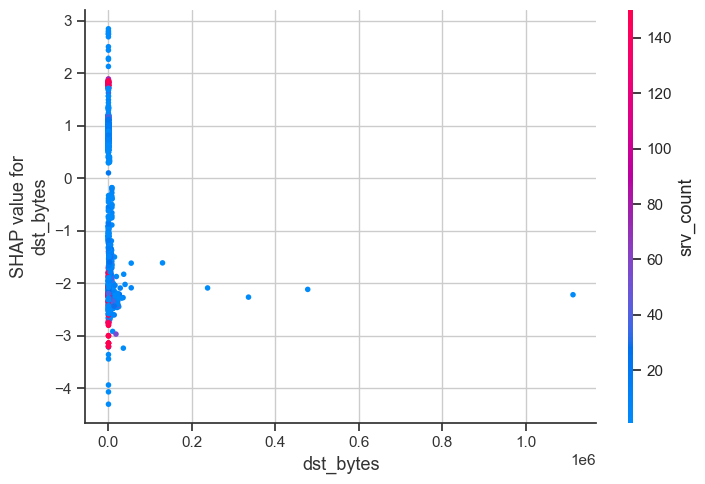

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_dependence_dst_bytes.png


In [14]:
for feat in top_features:
    shap.dependence_plot(feat, shap_pos, sample_X, show=False)
    plt.tight_layout()
    dep_path = os.path.join(FIG_DIR, f"shap_dependence_{feat}.png")
    plt.savefig(dep_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", dep_path)

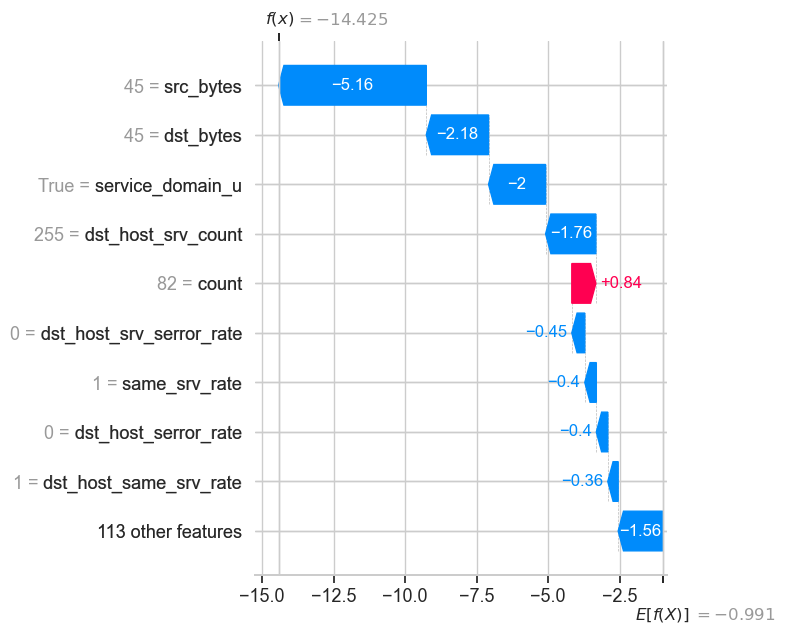

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_waterfall_sample0.png


In [15]:
sample_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_pos[sample_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=sample_X.iloc[sample_idx],
        feature_names=sample_X.columns
    ),
    show=False
)
plt.tight_layout()

waterfall_path = os.path.join(FIG_DIR, "shap_waterfall_sample0.png")
plt.savefig(waterfall_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", waterfall_path)

In [16]:
pred_test = model.predict(X_test)
print(classification_report(y_test, pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.78      0.77     22544



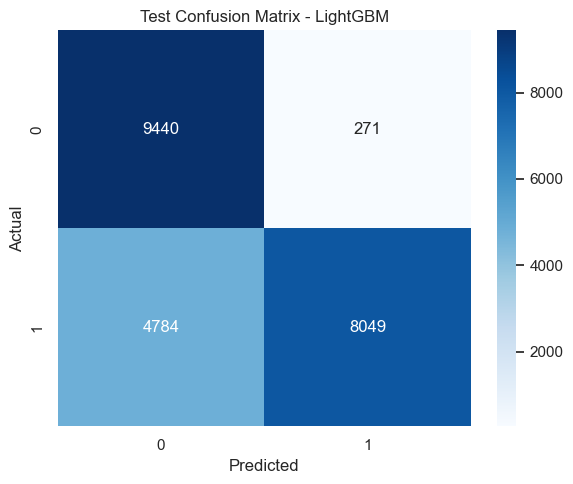

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\lightgbm_test_confusion_matrix.png


In [17]:
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

cm_path = os.path.join(FIG_DIR, "lightgbm_test_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [18]:
notes = []
notes.append("LightGBM + SHAP observations")
notes.append("=" * 40)
notes.append("1. LightGBM is the strongest baseline model on validation.")
notes.append("2. SHAP summary plot shows the most influential features globally.")
notes.append("3. Mean absolute SHAP values provide a clear ranking of feature importance.")
notes.append("4. Dependence plots help interpret how feature values shift predictions.")
notes.append("5. Waterfall plot gives a local explanation for one sample.")

notes_path = os.path.join(NOTES_DIR, "week4_shap_notes.txt")
with open(notes_path, "w", encoding="utf-8") as f:
    f.write("\n".join(notes))

print("Saved:", notes_path)

Saved: E:\Research\Paper_A_XAI_IDS\07_Notes\week4_shap_notes.txt


In [19]:
print("Explainability notebook complete.")
print("Next: refine the narrative and compare LightGBM SHAP with XGBoost if needed.")

Explainability notebook complete.
Next: refine the narrative and compare LightGBM SHAP with XGBoost if needed.


In [20]:
import joblib
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("XGBoost refit complete")

XGBoost refit complete


In [21]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(sample_X)

if isinstance(xgb_shap_values, list):
    xgb_shap_pos = xgb_shap_values[1]
else:
    xgb_shap_pos = xgb_shap_values

print(xgb_shap_pos.shape)

(2000, 122)


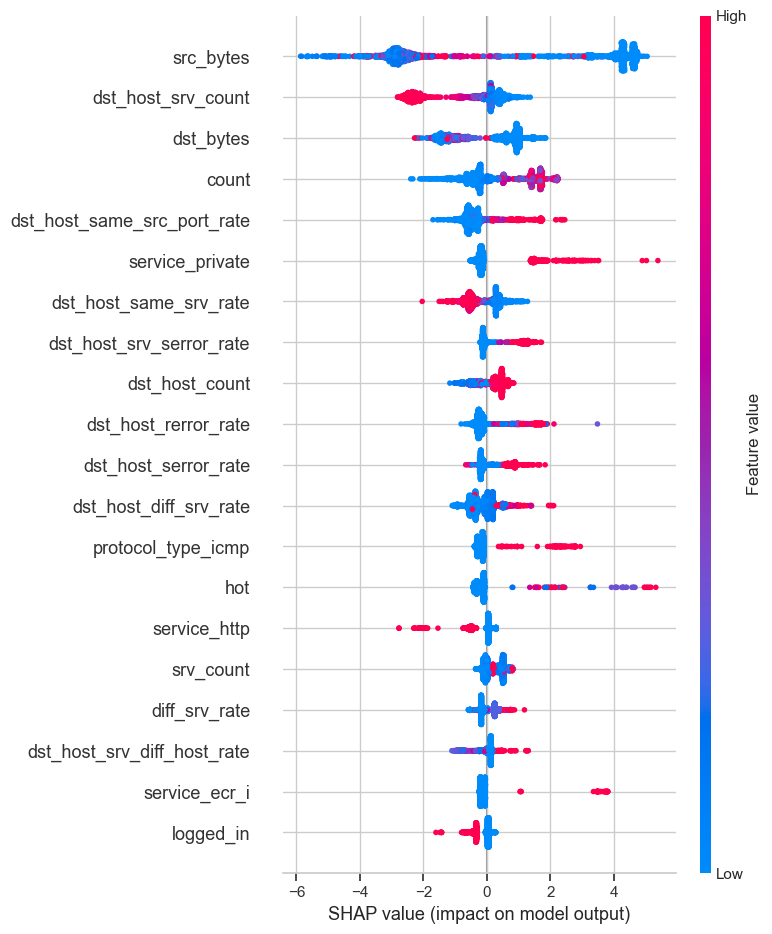

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_summary_xgboost_positive_class.png


In [22]:
shap.summary_plot(xgb_shap_pos, sample_X, show=False)
plt.tight_layout()

xgb_summary_path = os.path.join(FIG_DIR, "shap_summary_xgboost_positive_class.png")
plt.savefig(xgb_summary_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", xgb_summary_path)

In [23]:
xgb_mean_abs_shap = np.abs(xgb_shap_pos).mean(axis=0)
xgb_importance_df = pd.DataFrame({
    "feature": sample_X.columns,
    "mean_abs_shap": xgb_mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

xgb_importance_df.head(20)

,feature,mean_abs_shap
1,src_bytes,3.322382
29,dst_host_srv_count,1.026960
2,dst_bytes,0.992887
19,count,0.845687
32,dst_host_same_src_port_rate,0.554048
90,service_private,0.472401
30,dst_host_same_srv_rate,0.451173
35,dst_host_srv_serror_rate,0.417018
28,dst_host_count,0.389998
36,dst_host_rerror_rate,0.383292


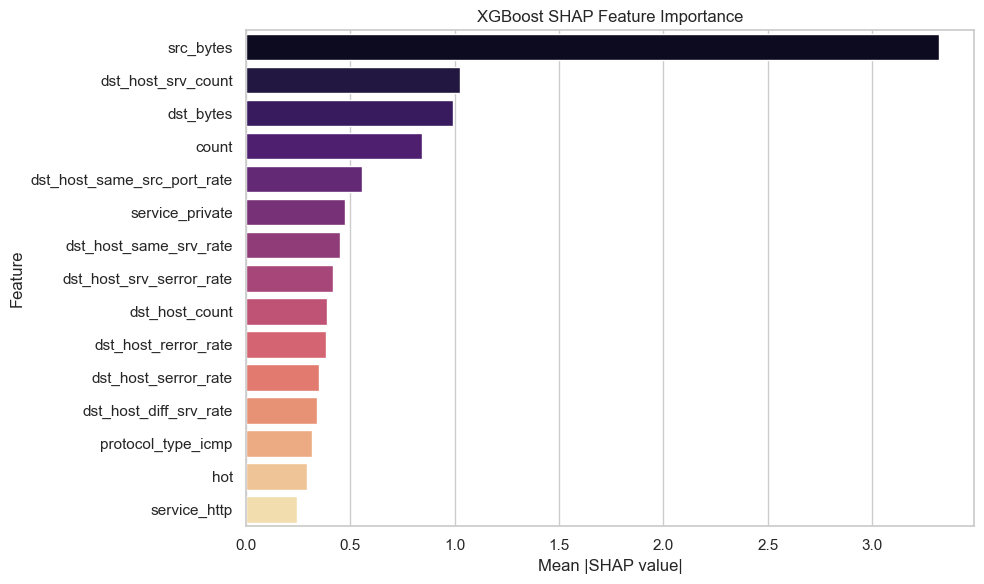

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\shap_feature_importance_xgboost.png


In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=xgb_importance_df.head(15), x="mean_abs_shap", y="feature", palette="magma")
plt.title("XGBoost SHAP Feature Importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()

xgb_bar_path = os.path.join(FIG_DIR, "shap_feature_importance_xgboost.png")
plt.savefig(xgb_bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", xgb_bar_path)

In [25]:
xgb_importance_path = os.path.join(RESULTS_DIR, "shap_feature_importance_xgboost.csv")
xgb_importance_df.to_csv(xgb_importance_path, index=False)
print("Saved:", xgb_importance_path)

Saved: E:\Research\Paper_A_XAI_IDS\04_Results\metrics\shap_feature_importance_xgboost.csv


In [26]:
xgb_top_features = xgb_importance_df["feature"].head(10).tolist()
lightgbm_top_features = importance_df["feature"].head(10).tolist()

overlap = list(dict.fromkeys([f for f in xgb_top_features if f in lightgbm_top_features]))
print("XGBoost top 10:", xgb_top_features)
print("LightGBM top 10:", lightgbm_top_features)
print("Overlap:", overlap)

XGBoost top 10: ['src_bytes', 'dst_host_srv_count', 'dst_bytes', 'count', 'dst_host_same_src_port_rate', 'service_private', 'dst_host_same_srv_rate', 'dst_host_srv_serror_rate', 'dst_host_count', 'dst_host_rerror_rate']
LightGBM top 10: ['src_bytes', 'dst_host_srv_count', 'dst_bytes', 'count', 'dst_host_srv_serror_rate', 'service_private', 'service_http', 'same_srv_rate', 'flag_S0', 'dst_host_same_srv_rate']
Overlap: ['src_bytes', 'dst_host_srv_count', 'dst_bytes', 'count', 'service_private', 'dst_host_same_srv_rate', 'dst_host_srv_serror_rate']


In [27]:
comparison_df = pd.DataFrame({
    "XGBoost_top10": pd.Series(xgb_top_features),
    "LightGBM_top10": pd.Series(lightgbm_top_features)
})
comparison_df

,XGBoost_top10,LightGBM_top10
0,src_bytes,src_bytes
1,dst_host_srv_count,dst_host_srv_count
2,dst_bytes,dst_bytes
3,count,count
4,dst_host_same_src_port_rate,dst_host_srv_serror_rate
5,service_private,service_private
6,dst_host_same_srv_rate,service_http
7,dst_host_srv_serror_rate,same_srv_rate
8,dst_host_count,flag_S0
9,dst_host_rerror_rate,dst_host_same_srv_rate


In [28]:
comparison_path = os.path.join(RESULTS_DIR, "xgb_lgbm_top10_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

Saved: E:\Research\Paper_A_XAI_IDS\04_Results\metrics\xgb_lgbm_top10_comparison.csv


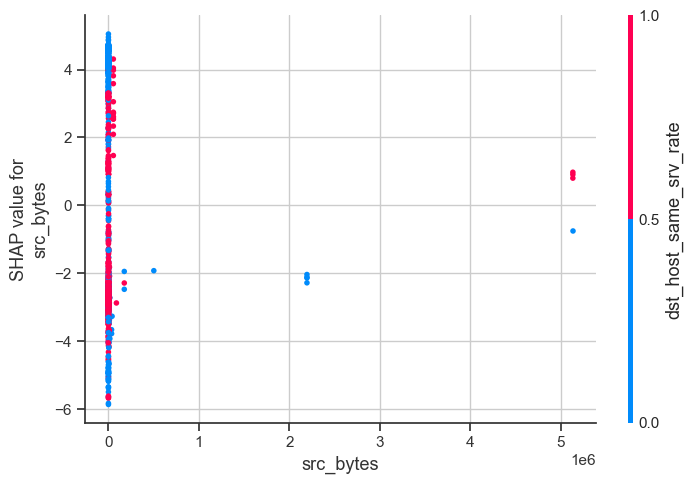

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\xgboost_shap_dependence_src_bytes.png


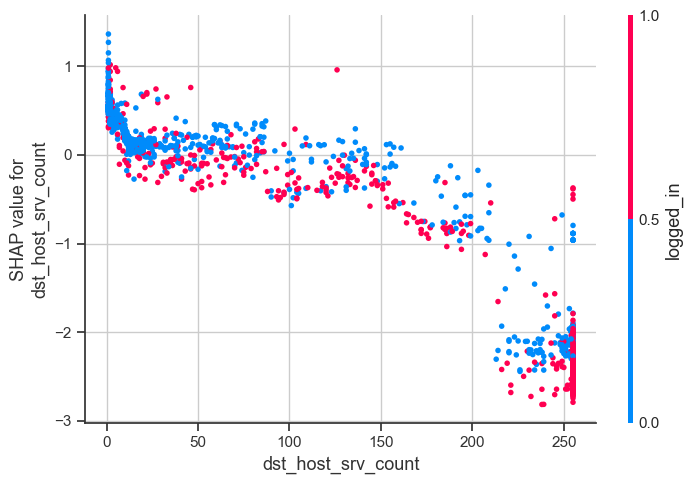

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\xgboost_shap_dependence_dst_host_srv_count.png


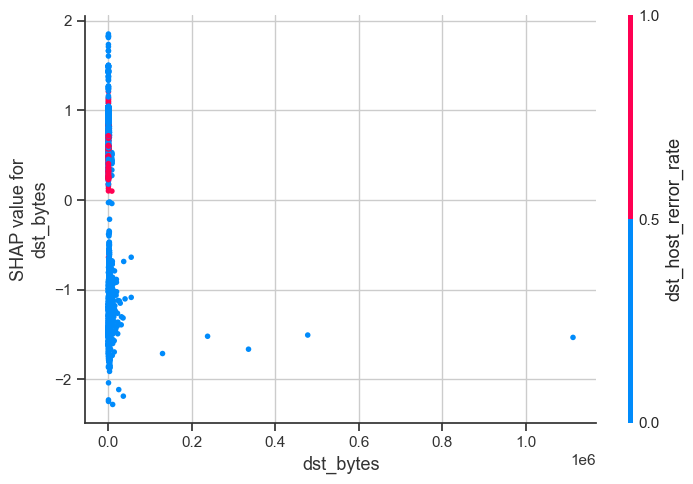

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\xgboost_shap_dependence_dst_bytes.png


In [29]:
common_top = overlap[:3]
for feat in common_top:
    shap.dependence_plot(feat, xgb_shap_pos, sample_X, show=False)
    plt.tight_layout()
    dep_path = os.path.join(FIG_DIR, f"xgboost_shap_dependence_{feat}.png")
    plt.savefig(dep_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", dep_path)

In [30]:
xgb_pred_test = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.81      0.79     22544
weighted avg       0.85      0.79      0.79     22544



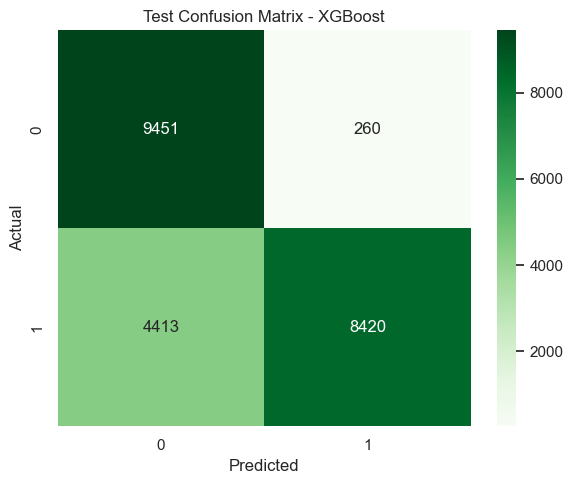

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\xgboost_test_confusion_matrix.png


In [31]:
xgb_cm = confusion_matrix(y_test, xgb_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Test Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

xgb_cm_path = os.path.join(FIG_DIR, "xgboost_test_confusion_matrix.png")
plt.savefig(xgb_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", xgb_cm_path)